In [2]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub


In [3]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))
print("Experiment: ResNet50 with Balanced Batch Sampling")
print("Expected batch composition: 16 NonDemented + 16 Demented")
print("Class weights: Disabled")

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Experiment: ResNet50 with Balanced Batch Sampling
Expected batch composition: 16 NonDemented + 16 Demented
Class weights: Disabled


In [4]:
dataset_path = Path(
    kagglehub.dataset_download(
        "aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented"
    )
)

image_root = dataset_path / "combined_images"

print("Dataset path:", dataset_path)
print("Image folder:", image_root)
print("Image folder exists:", image_root.exists())

Dataset path: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented
Image folder: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented/combined_images
Image folder exists: True


In [5]:
class_to_binary = {
    "NonDemented": 0,
    "VeryMildDemented": 1,
    "MildDemented": 1,
    "ModerateDemented": 1
}

records = []

for class_name, binary_label in class_to_binary.items():
    class_folder = image_root / class_name

    for image_path in sorted(class_folder.iterdir()):
        if image_path.suffix.lower() in {
            ".jpg", ".jpeg", ".png"
        }:
            records.append({
                "filepath": str(image_path),
                "original_class": class_name,
                "label": binary_label
            })

df = pd.DataFrame(records)

print("Total images:", len(df))

print("\nBinary class counts:")
print(df["label"].value_counts().sort_index())

print("\nOriginal class counts:")
print(df["original_class"].value_counts())

Total images: 44000

Binary class counts:
label
0    12800
1    31200
Name: count, dtype: int64

Original class counts:
original_class
NonDemented         12800
VeryMildDemented    11200
MildDemented        10000
ModerateDemented    10000
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

train_df, temporary_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    stratify=temporary_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training:", len(train_df), "images")
print(train_df["label"].value_counts().sort_index())

print("\nValidation:", len(validation_df), "images")
print(validation_df["label"].value_counts().sort_index())

print("\nTesting:", len(test_df), "images")
print(test_df["label"].value_counts().sort_index())

Training: 30800 images
label
0     8960
1    21840
Name: count, dtype: int64

Validation: 6600 images
label
0    1920
1    4680
Name: count, dtype: int64

Testing: 6600 images
label
0    1920
1    4680
Name: count, dtype: int64


In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
HALF_BATCH = BATCH_SIZE // 2
AUTOTUNE = tf.data.AUTOTUNE

def load_original_image(filepath, label):
    image = tf.io.read_file(filepath)

    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    label = tf.cast(
        label,
        tf.float32
    )

    return image, label

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Images from each class per batch:", HALF_BATCH)

Image size: (224, 224)
Batch size: 32
Images from each class per batch: 16


In [8]:
class_0_df = train_df[
    train_df["label"] == 0
].reset_index(drop=True)

class_1_df = train_df[
    train_df["label"] == 1
].reset_index(drop=True)


def create_repeated_class_dataset(class_df):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            class_df["filepath"].values,
            class_df["label"].values
        )
    )

    dataset = dataset.shuffle(
        buffer_size=len(class_df),
        seed=SEED,
        reshuffle_each_iteration=True
    )

    dataset = dataset.repeat()

    dataset = dataset.map(
        load_original_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        HALF_BATCH,
        drop_remainder=True
    )

    return dataset


class_0_dataset = create_repeated_class_dataset(
    class_0_df
)

class_1_dataset = create_repeated_class_dataset(
    class_1_df
)


def merge_balanced_batches(batch_0, batch_1):
    images = tf.concat(
        [batch_0[0], batch_1[0]],
        axis=0
    )

    labels = tf.concat(
        [batch_0[1], batch_1[1]],
        axis=0
    )

    indices = tf.random.shuffle(
        tf.range(BATCH_SIZE)
    )

    return (
        tf.gather(images, indices),
        tf.gather(labels, indices)
    )


balanced_train_dataset = tf.data.Dataset.zip(
    (class_0_dataset, class_1_dataset)
)

balanced_train_dataset = balanced_train_dataset.map(
    merge_balanced_batches,
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)


def create_evaluation_dataset(dataframe):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            dataframe["filepath"].values,
            dataframe["label"].values
        )
    )

    dataset = dataset.map(
        load_original_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


validation_dataset = create_evaluation_dataset(
    validation_df
)

test_dataset = create_evaluation_dataset(
    test_df
)

STEPS_PER_EPOCH = int(
    np.ceil(len(train_df) / BATCH_SIZE)
)

print("Class 0 training images:", len(class_0_df))
print("Class 1 training images:", len(class_1_df))
print("Steps per epoch:", STEPS_PER_EPOCH)

I0000 00:00:1789366393.566116      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Class 0 training images: 8960
Class 1 training images: 21840
Steps per epoch: 963


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel range: 0.0 to 255.0
NonDemented in batch: 16
Demented in batch: 16


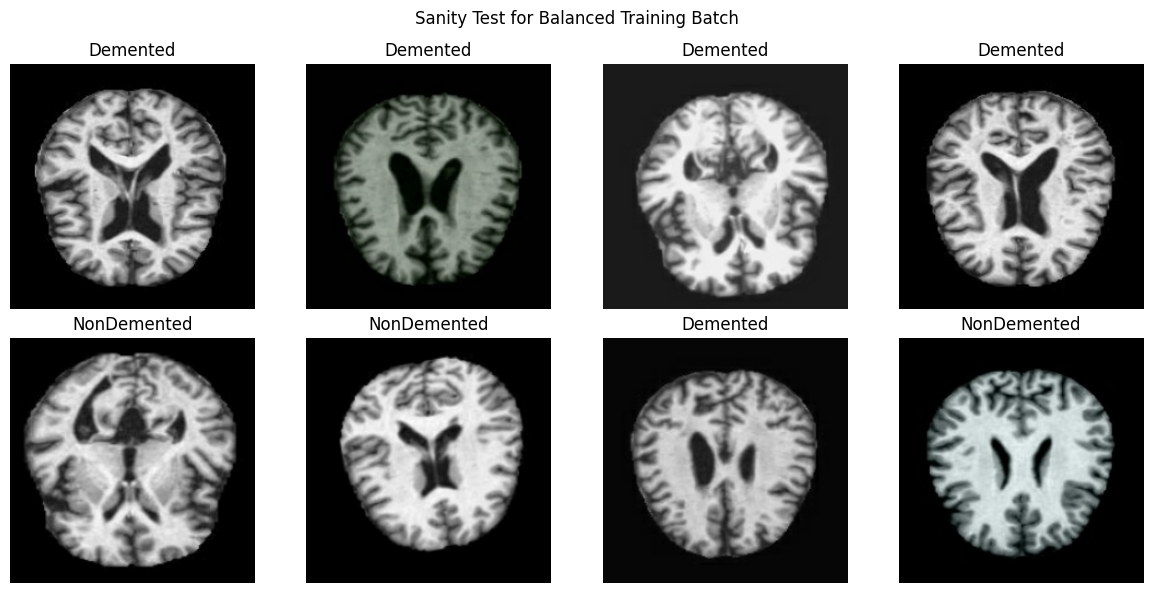

In [9]:
for images, labels in balanced_train_dataset.take(1):
    class_0_count = int(
        tf.reduce_sum(
            tf.cast(labels == 0, tf.int32)
        ).numpy()
    )

    class_1_count = int(
        tf.reduce_sum(
            tf.cast(labels == 1, tf.int32)
        ).numpy()
    )

    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Pixel range:", images.numpy().min(), "to", images.numpy().max())
    print("NonDemented in batch:", class_0_count)
    print("Demented in batch:", class_1_count)

    plt.figure(figsize=(12, 6))

    for index in range(8):
        plt.subplot(2, 4, index + 1)
        plt.imshow(
            tf.cast(images[index], tf.uint8)
        )

        class_name = (
            "Demented"
            if labels[index].numpy() == 1
            else "NonDemented"
        )

        plt.title(class_name)
        plt.axis("off")

    plt.suptitle(
        "Sanity Test for Balanced Training Batch"
    )
    plt.tight_layout()
    plt.show()

In [10]:
MAX_EPOCHS = 30
PATIENCE = 5
LEARNING_RATE = 0.0001
DROPOUT_RATE = 0.30

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Maximum epochs:", MAX_EPOCHS)
print("Early-stopping patience:", PATIENCE)
print("Learning rate:", LEARNING_RATE)
print("Dropout rate:", DROPOUT_RATE)
print("Steps per epoch:", STEPS_PER_EPOCH)

print("Preprocessing: Original images")
print("Data augmentation: Disabled")
print("Balanced batches: Enabled")
print("Class weights: Disabled")

Image size: (224, 224)
Batch size: 32
Maximum epochs: 30
Early-stopping patience: 5
Learning rate: 0.0001
Dropout rate: 0.3
Steps per epoch: 963
Preprocessing: Original images
Data augmentation: Disabled
Balanced batches: Enabled
Class weights: Disabled


In [11]:
resnet_base = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

resnet_base.trainable = False

inputs = tf.keras.Input(
    shape=(224, 224, 3)
)

x = tf.keras.applications.resnet50.preprocess_input(
    inputs
)

x = resnet_base(
    x,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(
    DROPOUT_RATE
)(x)

outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="ResNet50_Balanced_Batches"
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Total parameters:", model.count_params())

print(
    "Trainable parameters:",
    sum(
        tf.keras.backend.count_params(weight)
        for weight in model.trainable_weights
    )
)

print("ResNet50 frozen:", not resnet_base.trainable)
print("Dropout rate:", DROPOUT_RATE)
print("Balanced batches enabled: True")

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Total parameters: 23589761
Trainable parameters: 2049
ResNet50 frozen: True
Dropout rate: 0.3
Balanced batches enabled: True


Model: "ResNet50_Balanced_Batches"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      2,049 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [13]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/resnet50_balanced_batches_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [14]:
history = model.fit(
    balanced_train_dataset,
    validation_data=validation_dataset,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=MAX_EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
  3/963 ━━━━━━━━━━━━━━━━━━━━ 46s 49ms/step - accuracy: 0.5729 - loss: 0.7811   

I0000 00:00:1789366585.076219     140 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


962/963 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6225 - loss: 0.6762
Epoch 1: val_loss improved from None to 0.50285, saving model to /kaggle/working/resnet50_balanced_batches_best.keras

Epoch 1: finished saving model to /kaggle/working/resnet50_balanced_batches_best.keras
963/963 ━━━━━━━━━━━━━━━━━━━━ 89s 80ms/step - accuracy: 0.6700 - loss: 0.6163 - val_accuracy: 0.7595 - val_loss: 0.5028 - learning_rate: 1.0000e-04
Epoch 2/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7378 - loss: 0.5333
Epoch 2: val_loss improved from 0.50285 to 0.47580, saving model to /kaggle/working/resnet50_balanced_batches_best.keras

Epoch 2: finished saving model to /kaggle/working/resnet50_balanced_batches_best.keras
963/963 ━━━━━━━━━━━━━━━━━━━━ 57s 60ms/step - accuracy: 0.7426 - loss: 0.5255 - val_accuracy: 0.7723 - val_loss: 0.4758 - learning_rate: 1.0000e-04
Epoch 3/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7478 - loss: 0.5043
Epoch 3: val_loss improved from 0.47580 t